<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Libraries
!pip install -q langchain langchain-huggingface transformers torch matplotlib

In [ ]:
# Imports
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
import matplotlib.pyplot as plt
import time

In [ ]:
# Load Local Model
pipe = pipeline(
    "text-generation",
    model="distilgpt2",
    max_new_tokens=40,
    do_sample=True,
    temperature=0.7,
    repetition_penalty=1.5
)

llm = HuggingFacePipeline(pipeline=pipe)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Prompt Template
prompt = PromptTemplate.from_template(
    "Complete the sentence:\n{topic}"
)

In [ ]:
# Create Chain (NEW STYLE)
chain = prompt | llm

In [ ]:
# Topics
topics = [
    "Time management is important because",
    "A healthy lifestyle helps us to",
    "Good communication allows people to",
    "Stress can affect our life by",
    "Habits are formed when we"
]

In [ ]:
# Run Model
times = []

for i, topic in enumerate(topics):
    start = time.time()

    response = chain.invoke({"topic": topic})

    end = time.time()

    times.append(end - start)

    print(f"\nTopic {i+1}: {topic}")
    print(f"Response: {response.strip()}")


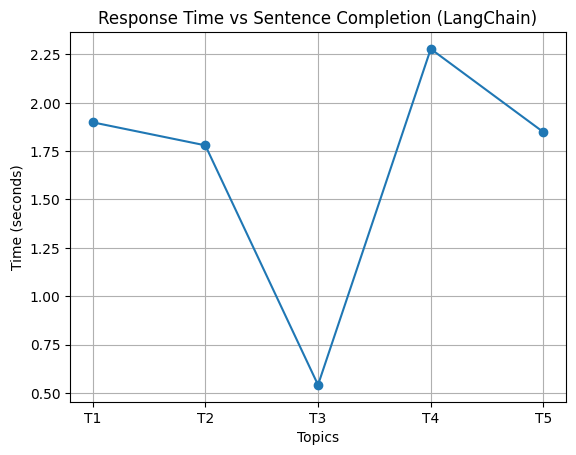

In [ ]:
# Graph
plt.figure()

plt.plot(range(1, len(times)+1), times, marker='o')

plt.title("Response Time vs Sentence Completion (LangChain)")
plt.xlabel("Topics")
plt.ylabel("Time (seconds)")

plt.xticks(range(1, len(topics)+1), ["T1","T2","T3","T4","T5"])

plt.grid(True)
plt.show()